<h1><center>A Buffet of Bayesian Data Analysis</center></h1>
<h2><center>UT 1403-2 Probability 1 Project</center></h2>
<h3><center>by RKSY</h3><center>

The following python packages are used in this project:
- SciPy
- Matplotlib
- NumPy
- Pandas

## Setup: [Blue Monday](https://www.youtube.com/watch?v=c1GxjzHm5us)

We have taken interest in knowing the proportion of students that would choose Monday as their favorite day to enjoy breakfast at the university buffet. The data we have observed is a family {$X_{i}$} of n binary random valuables, where $X_{i}$ is 1 iff the i-th person that was asked about their favorite day answered with "Monday" and is 0 otherwise. We operate under the assumption that the $X_{i}$ are i.i.d. Bernoulli R.V.s with the common parameter $\theta$. Our expert, whose opinions and experience we shall incorporate in our Bayesian analysis of the data, is the buffet manager Agha Ghader.

## 1: Discrete Prior

After conversing with our expert, we have obtained a prior distribution for $\theta$ with support $$\theta \in \{0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0\}$$ and the prior PDF:
$$\mathbb{P}(\theta = k) = f(k) = \begin{cases}
0.05 & \text{if } k \in \{0.1, 0.2, 0.9, 1.0\}\\
0.1 & \text{if } k \in \{0.3, 0.4, 0.7, 0.8\}\\
0.2 & \text{if } k \in \{0.5, 0.6\}\\
\end{cases}$$
which can be displayed as such:

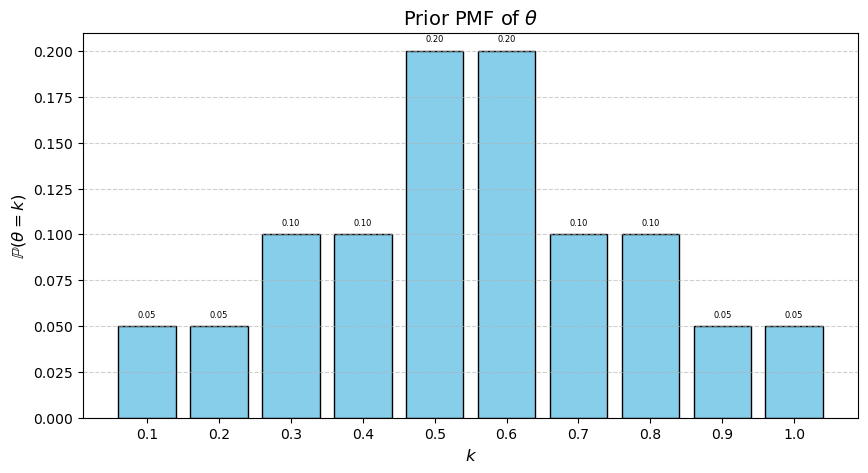

In [12]:
import matplotlib.pyplot as plot
domain = [(k/10) for k in range(1, 11)]
image = [0.05, 0.05, 0.1, 0.1, 0.2, 0.2, 0.1, 0.1, 0.05, 0.05]

plot.figure(figsize=(10, 5))
plot.bar(domain, image, width= 0.08, color='skyblue', edgecolor= 'black')
plot.xticks(domain)
plot.grid(axis='y', linestyle='--', alpha=0.6)
for k, p in zip(domain, image):
    plot.text(k, p + 0.005, f'{p:.2f}', ha='center', fontsize=6)

plot.xlabel('$k$', fontsize=12)
plot.ylabel('$\\mathbb{P}(\\theta = k)$', fontsize=12)
plot.title('Prior PMF of $\\theta$', fontsize=14); 

We now gather data. Having asked $n = 20$ students which day they prefer, $s = 12$ of them have responded with monday, meaning we have a sample proportion of $\frac{12}{20}$. We shall use this data and, of course, our beloved Bayes' Theorem to obtain a posterior distribution for $\theta$. As a reminder, **Bayes' Theorem** states:
$$\mathbb{P}(\theta \mid X) = \frac{\mathbb{P}(X \mid \theta) \cdot \mathbb{P}(\theta)}{\mathbb{P}(X)}$$
Where $\mathbb{P}(\theta \mid X)$ is the posterior we desire, $\mathbb{P}(\theta)$ is the prior we have, $\mathbb{P}(X \mid \theta)$ is referred to as the likelihood function, and we shall refer to $\mathbb{P}(X)$ simply as _evidence_, though it is also known as the marginal likelihood, the prior predictive and the normalizing constant.

However, as mentioned in the setup, our $X$ is not a singular entity but rather a family $\{X_i\}$ of data. One of the advantages of Bayesian analysis is that it allows for both sequential analysis and one-step analysis. As in we could consider the data collectively, as a whole; or we could compute the posterior for the first datum $X_1$, and then use this posterior as our prior for incorporating the second datum $X_2$, and then use the new posterior for the third datum and so on. It can be proven that both of these approaches will give the same result.

However, in case of simple i.i.d. binary data such as the one we have, we needn't complicate things with sequential analysis. We can consider our family of i.i.d. Bernoulli data to be the result of a draw from one Binomial distribution with parameter $\theta$, and so one-step analysis becomes easy.

if we define consider our data as having a Binomial distribution with $n = 20$ trials, and consider $y$ to be the amount of successes (the Binomial R.V. itself, we use y insead of s here to match the common notation for observed data in Bayesian inference) then we have $y \sim Binomial(20, \theta)$ and $y = 12$. To compute the likelihood of this given a certain $\theta$, we have:
$$\mathbb{P}(\{X_i\} \mid \theta) = \mathbb{P}(y = 12 \mid \theta) = {20 \choose 12} \cdot \theta^{12} \cdot (1 - \theta)^8 = 125970 \cdot \theta^{12} \cdot (1 - \theta)^8$$
As we already have the priors, we simply need to multiply the likelihood for each $\theta$ by the relevant prior to gain the unnormalized posterior for that Theta.
$$\mathbb{P}(\theta \mid y = 12) \propto \mathbb{P}(y = 12 \mid \theta) \cdot \mathbb{P}(\theta)$$
All we are missing now is the evidence $\mathbb{P}(y = 12) = \mathbb{P}(\{X_i\})$. To find this, note that since we know all possible values of $\theta$ we can use LOTP to say:
$$\mathbb{P}(y = 12) = \sum_{\Theta \in support(\theta)} \mathbb{P}(y = 12 \mid \Theta) \cdot \mathbb{P}(\Theta) $$
Meaning that we only need to sum all the unnormalized posteriors we've already obtained to gain the normalization constant, and then by dividing each unnormalized posterior by this constant (which is, indeed, _normalizing_ it) we gain the posterior for each $\theta$.

In [63]:
import pandas as pd
theta = [(k/10) for k in range(1, 11)]
prior = [0.05, 0.05, 0.1, 0.1, 0.2, 0.2, 0.1, 0.1, 0.05, 0.05]
# data = 12/20, so 12 successes and 8 failures.

likelihood = []
for i in range(10):
    likely = 125970*((theta[i])**12)*((1 - theta[i])**8)
    likelihood.append(likely)
    
unnormalized_posterior = []
for i in range(10):
    unpost = likelihood[i] * prior[i]
    unnormalized_posterior.append(unpost)
    
evidence = sum(unnormalized_posterior)
print("Our normalization constant is " + str(evidence))
print("And we can neatly display everything in a table like so:")
posterior = []
for i in range(10):
    post = unnormalized_posterior[i] / evidence
    posterior.append(post)

EVERYTHINGISANINDEX = ['Θ', 'Prior', 'Likelihood', 'Unnormalized Posterior', 'Posterior']
table = pd.DataFrame({
    'Θ': theta,
    'Prior': prior,
    'Likelihood': likelihood,
    'Unnormalized Posterior': unnormalized_posterior,
    'Posterior': posterior
}).set_index(EVERYTHINGISANINDEX)

table

Our normalization constant is 0.07758158190561164
And we can neatly display everything in a table like so:


,,,,
Θ,Prior,Likelihood,Unnormalized Posterior,Posterior
0.1,0.05,5.422595e-08,2.711298e-09,3.494770e-08
0.2,0.05,8.656592e-05,4.328296e-06,5.579026e-05
0.3,0.10,3.859282e-03,3.859282e-04,4.974482e-03
0.4,0.10,3.549744e-02,3.549744e-03,4.575498e-02
0.5,0.20,1.201344e-01,2.402687e-02,3.096981e-01
0.6,0.20,1.797058e-01,3.594116e-02,4.632692e-01
0.7,0.10,1.143967e-01,1.143967e-02,1.474535e-01
0.8,0.10,2.216088e-02,2.216088e-03,2.856461e-02
0.9,0.05,3.557765e-04,1.778882e-05,2.292918e-04


We not that the probability of $\theta = 1$ is zero because we've had 8 people that said Monday was not their favorite day, and if $\theta$ was $1$ then no one would have said that. If we had included $\theta = 0$ in our support, it's posterior probability would similarly be zero because we've had at least one person (in fact, 12 people!) choose Monday.

Another easy way to check our work is to note that since the posteriors are _normalized_ probabilities and the possible values of $\theta$ are a partition of our probability space $\Omega$, then they must sum to 1.

In [7]:
print(sum(posterior))

1.0


It seems we've done our job well so far! now to answer some questions:

The most likely values of $\theta$ **before** observing the data were 0.5 and 0.6, both having 0.2 probability. (_prior_ probability).

The most likely value of $\theta$ **after** observing the data is 0.6, with probability 0.4632692021498749 (_posterior_ probability).

The posterior probability that $\theta > 0.5$ is:

$$
P(\theta \geq 0.6 \mid \{X_i\}) = \sum_{j=6}^{10} P\left(\theta = \frac{j}{10} \mid \{X_i\}\right)
$$

Which can be calculated like so.

In [28]:
gtfive = posterior[5:10]
print(sum(gtfive))

0.6395165811668709


We can see the desired probability is:
$$
P(\theta \geq 0.6 \mid \{X_i\}) \approx 0.6395
$$

Additionally, to plot the Posterior PDF, we can simply re-use our code from before with the posterior priorities now serving the role of the image for the function.

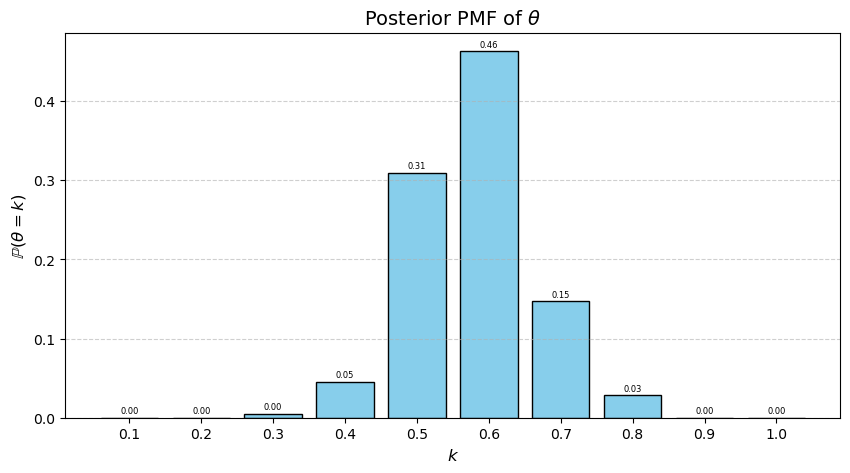

In [14]:
import matplotlib.pyplot as plot
domain = [(k/10) for k in range(1, 11)]
image = [3.4947698352988705e-08, 5.5790255056708114e-05, 0.004974482133654501, 0.045754982928382704, 0.3096981285683368, 0.4632692021498749, 0.14745347657906757, 0.02856461058903449, 0.00022929184889395837, 0.0]

plot.figure(figsize=(10, 5))
plot.bar(domain, image, width= 0.08, color='skyblue', edgecolor= 'black')
plot.xticks(domain)
plot.grid(axis='y', linestyle='--', alpha=0.6)
for k, p in zip(domain, image):
    plot.text(k, p + 0.005, f'{p:.2f}', ha='center', fontsize=6)

plot.xlabel('$k$', fontsize=12)
plot.ylabel('$\\mathbb{P}(\\theta = k)$', fontsize=12)
plot.title('Posterior PMF of $\\theta$', fontsize=14);

Although the graph above makes it seem like `0.1, 0.2 & 0.9` also have a probability of 0, the truth is that the probabilities for $\theta$ taking on any of these numbers is simply too small to be seen on the graph above. to actually observe them, we must stretch the Y-axis to a ridiculous degree. I recommend you try this for yourself by increasing the value for the second argument (which i've set to 5) in the line `plot.figure(figsize=(10, 5))`.

## 2: Continuous Prior

Here is the question we must now answer:

**What would we do if we had no expert? What would we do if we had no prior information at all?**

Indeed, it is quite rare for a working data scientist or statistician to have access to a complete PDF such as the one we had before. Often, experts can't confidently determine a support for the parameter in question and then assign an exact probability value to each member of that support. In such cases, we can ask them for more intuitive summaries of the parameter which may come more easily to them. For example, we could ask our expert what they think the mean value of the possible values for our parameter should be, and what interval are they 95% certain the parameter will fall into.

Having no access to an expert at all forces us to come up with creative measures of our own. If, in addition to lacking an expert, we do not have any information about $\theta$ whatsoever, then we can use the Principle of Insufficient Reason (also known as the principle of indifference or simply as using naïveté), which states: "in the absence of any relevant evidence, agents should distribute their credence (or "degrees of belief") equally among all the possible outcomes under consideration."
This is all a fancy way to say that, in such a scenario, we would assume $\theta \sim Uniform(0, 1)$.

However, it is rarely the case that we have _no information at all_, as casual observations and what we consider "common sense" both provide valuable information. In our example: Common sense would be noting that even if the buffet is open on days where no classes are held at the university, it'd be very unusual for someone to have breakfast at the buffet on an off-day, never mind it being their _favorite_ day to do so. A casual observation would be simply calling upon your own experience as to how busy you remember mondays in the buffet being.

In this section, we shall work with three different priors, each of which stems from different assumptions. First, we shall assume naïveté and assign a Uniform distribution to $\theta$.
Secondly, we shall assume that Monday is a popular choice amongst students and use a right skewed distribution for $\theta$. Thirdly, we shall assume that monday is an *un*popular choice amongst students and use a left skewed distribution for $\theta$. For the second and third cases, we will be constructing a Beta PDF and for each case we will be deriving the posterior and answering the three questions listed below:
1. What is the most likely value (mode) of $\theta$ after observing the data?
2. What is the posterior probability that $\theta$ > 0.5?
3. What is a 95% credible interval for $\theta$?

Here we encounter a problem: **How are we to compute the posterior when our prior PDF is not discrete and so we can't use the different values of $\theta$ as a partition of $\Omega$ for LOTP?** Can we perhaps come up with a version of the Law of Total Probability that uses an uncountable, continuous partition of $\Omega$?
As a reminder:
$$\text{LOTP, also known as marginalization, states}: \mathbb{P}(X) = \sum_{i = 1}^{n} \mathbb{P}(X \mid P_i) \cdot \mathbb{P}(P_i)$$
where $\{A_i\}_{i=1}^{n}$ is a partition of $\Omega$. Now, if we let $n \rightarrow \infty$ the size of each $A_i$ becomes smaller and smaller, allowing our partitioning to become finer and finer and the sum above comes quite close indeed to resembling a Riemann sum! And so, remembering $\mathbb{P}(X \cap Y) = \mathbb{P}(X \mid Y)\mathbb{P}(Y)$, we can conclude:
$$\mathbb{P}(X) = \int_{-\infty}^{\infty} \mathbb{P}(X \cap Y)dY$$
However, figuring out the identity of dY becomes troublesome here and could make our proof unwieldy. Instead, now that we know we must reach an integral in the end, let us use a little fact from Andrew Gelman's Bayesian Data Analysis 3e (equation 1.8 of BDA3, specifically) along with a spice of ingenuity to find an identity we can use.
$$\text{The Law of Total Expectation: } E(u) = E(E(u \mid v))$$
Where the inner expectation averages over u, conditional on v, and the outer expectation
averages over v. this can be easily proven using the definition of Expectation. Suppose that our R.V. X has PDF f and A is an event, we can say:
$$\mathbb{P}(A) = E(I_A) = E(E(I_A \mid X)) = \int_{-\infty}^{\infty} E(I_A \mid X=x)f(x)dx = \int_{-\infty}^{\infty} \mathbb{P}(A \mid X=x)f(x)dx$$
Now, if we consider $X=x$ as the event $\theta$ and replace A with y to match the common notation for observed data in Bayesian statistics, We have $f(x) = \mathbb{P}(X=x) = \mathbb{P}(\theta)$, which gives us:
$$\mathbb{P}(y) = \int_{-\infty}^{\infty} \mathbb{P}(y \mid \theta) \mathbb{P}(\theta) d\theta$$
Although this proof isn't perfect, and there are things to nitpick (e.g. simply writing $X=x$ could lead to misunderstanding, as for any continuous random variables this event has probability 0. in fact, what we are taking into account here is the partition set of events $\{\{X = x\} \mid x \in \mathbb{R}\}$), because the nature of this project is more practical than theoretical, and there is no need for such rigor, we shall simply accept the Continuous LOTP formula and look at the proof above as a way of obtaining more intuition as to how all this came about.

### 2.1: Uniform Prior

Assuming $\theta \sim Uniform(0, 1)$ means we're assigning the below PDF to $\theta$:
$$\mathbb{P}(\theta = x) = f(x) = \begin{cases}
1 & \text{if } 0 < x < 1\\
0 & \text{if } otherwise\\
\end{cases}$$
Using the fact that $Uniform(0,1) \sim Beta(1,1)$, we can plot the former like so:

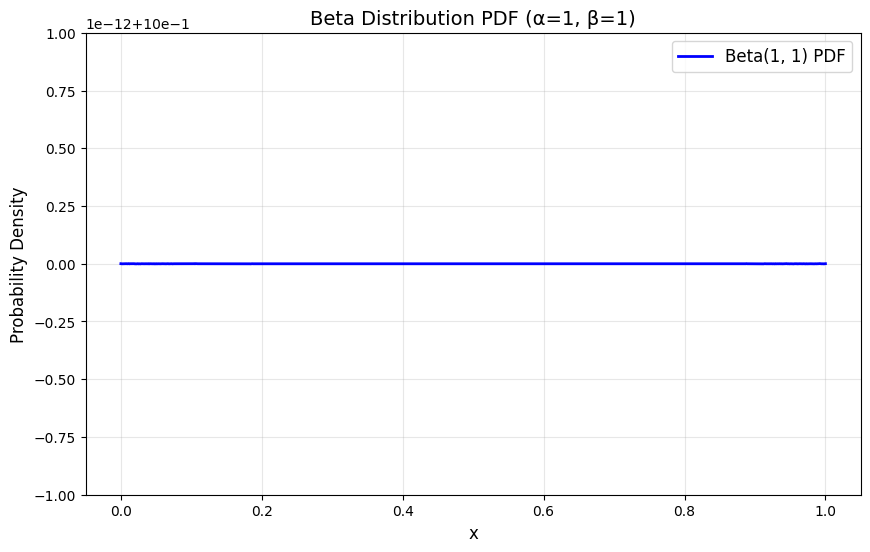

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def plotbeta(a, b):
    x = np.linspace(0, 1, 1000)
    pdf_values = beta.pdf(x, a, b)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, pdf_values, 'b-', linewidth=2, label=f'Beta({a}, {b}) PDF')
    plt.title(f'Beta Distribution PDF (α={a}, β={b})', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.show()

plotbeta(1, 1)


And the below CDF:
$$\mathbb{P}(\theta \leq x) = F(x) = \begin{cases}
0 & \text{if } x \leq 0\\
x & \text{if } 0 < x < 1\\
1 & \text{if } x \geq 1\\
\end{cases}$$
Which tells us that, constrained to the interval from 0 to 1, probability _is_ length for the Standard Uniform distribution.
Let us write down what we wish to find.
$$\mathbb{P}(\theta \mid y = 12) = \frac{\mathbb{P}(y = 12 \mid \theta)\mathbb{P}(\theta)}{\mathbb{P}(y = 12)}$$
Now we compute step by step.
- $\mathbb{P}(\theta) = 1$ for $\theta \in [0, 1]$
- $\mathbb{P}(y=12 \mid \theta) = {20 \choose 12} \theta^{12} (1-\theta)^{8}$
- $\mathbb{P}(y=12) = \int_0^1\mathbb{P}(y=12 \mid \theta)\mathbb{P}(\theta)d\theta = \int_0^1 {20 \choose 12}\theta^{12} (1-\theta)^{8}d\theta = {20 \choose 12} \int_0^1\theta^{12} (1-\theta)^{8}d\theta = {20 \choose 12} B(13, 9)$

Where, in the last step we encountered the beta function. Bringing it together, we have:
$$\mathbb{P}(\theta \mid y = 12) = \frac{{20 \choose 12} \theta^{12} (1-\theta)^{8}}{{20 \choose 12}B(13, 9)} = \frac{\theta^{12} (1-\theta)^{8}}{B(13, 9)}$$
Therefore, we can conclude that the posterior distribution for $\theta$ is:  $$\mathbb{P}(\theta \mid y=12) \sim Beta(13, 9)$$

We could have reached this conclusion much faster by noting that in $\mathbb{P}(y=12 \mid \theta) = {20 \choose 12} \theta^{12} (1-\theta)^{8}$, we can ignore ${20 \choose 12}$ which is a constant. What remains, $\theta^{12} (1-\theta)^{8}$, is the _kernel_ of the $Beta(13,9)$ distribution. We know that our distribution must be normalized (i.e. integrate to one on its domain of [0,1]) and the only denominator that could normalize ${20 \choose 12} \theta^{12} (1-\theta)^{8}$ is it's own integral from 0 to 1, which is indeed exactly ${20 \choose 12} B(13, 9)$.

An easier method to find posteriors such as the one above is to simply recognize *conjugate* priors and likelihoods. **Conjugacy** is defined as "The property that the posterior distribution follows the same parametric form as the
prior distribution", and the Beta prior distribution is a conjugate family for
the Binomial likelihood.
This means that if we have a Binomial likelihood, and choose a Beta function as our prior, then we shall receive a Beta function after calculating our poster (which is exactly what we saw above!). The crucial observation comes from knowing $Uniform(0, 1) \sim Beta(1, 1)$. Knowing this, we can simply use the conjugacy formulas displayed below:
For Binomial data $y \sim Binomial(n, \theta)$ and Beta prior $\theta \sim Beta(\alpha, \beta)$ we have the posterior distribution:
$$\theta \mid y \sim Beta(\alpha + y, \beta + n - y)$$
One may note that the parameters for the posterior are a compromise between the prior and the observed data; and the compromise is such that as the amount of data increases, the sway of the prior parameters decreases. The information we have is:
- $\theta \sim Uniform(1, 0) \sim Beta(1, 1)$ which means $\alpha = \beta = 1$
- $y \sim Binomial(20, \theta)$, which means $n = 20$
- $y = 12$

Applying the formula gives us:
$$\theta \sim Beta(1+12,1+20-12) = Beta(13, 9)$$
Which can be plotted with the same code we wrote above:

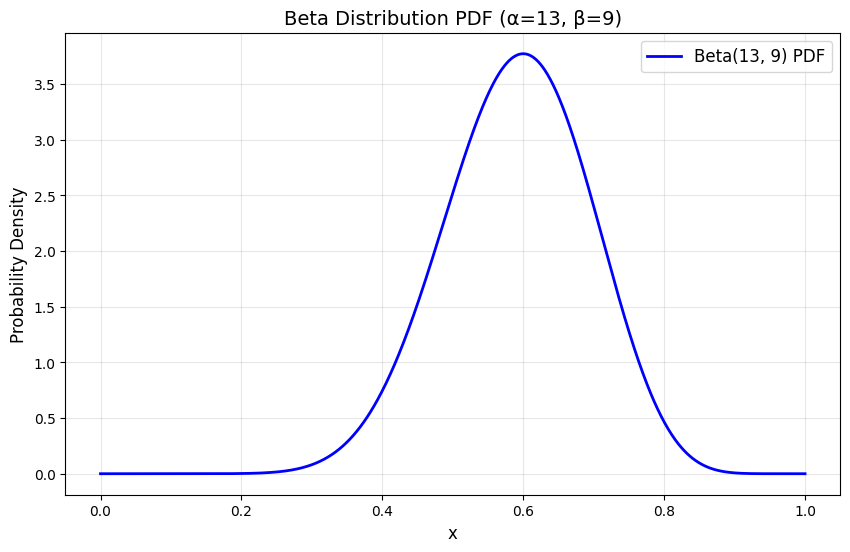

In [36]:
plotbeta(13, 9)

**3 Questions**

According to Continuous Univariate Distributions by Johnson, Kotz & Balakrishnan; The mode of a $Beta(\alpha, \beta)$ distribution is given by:
$$mode = \frac{\alpha - 1}{\alpha + \beta - 2}$$

1. Inserting $\alpha = 13$ and $\beta = 9$ gives us:
$$mode = \frac{13 - 1}{13 + 9 - 2} = \frac{12}{20} = 0.6$$

2. $\mathbb{P}(\theta > 0.5 \mid y=12) = 1 - \mathbb{P}(\theta \leq 0.5 \mid y=12) = 1 - F(0.5)$

Where F is the posterior CDF of $\theta$. This can be calculated using SciPy.

In [35]:
from scipy.stats import beta
print(1 - beta.cdf(0.5, 13, 9))

0.808344841003418


As we can see the desired probability is:
$$
P(\theta > 0.5 \mid \{X_i\}) \approx 0.8083
$$
We can also go ahead and calculate the mean like so:

In [57]:
from scipy.stats import beta
print(beta.mean(13, 9))

0.5909090909090909


A note on **Credible Intervals**.

A $100(1-\alpha)%$ credible interval for a parameter $\theta$ is an interval $[a, b]$ such that there is an $1-\alpha%$ chance that $\theta \in [a, b]$. A $100(1-\alpha)%$ *central* credible interval is a $100(1-\alpha)%$ credible interval that includes the *middle* $100(1-\alpha)%$ of the distribution, leaving $\frac{\alpha}{2}$ at each tail end. Basically, a 95% central credible interval symmetrically excludes 2.5% of the probability mass from both tails of the posterior distribution.

For a Beta-distributed $\theta$ parameter with support $[0,1]$, this means cutting off the lowest 2.5% of values (below the 0.025 quantile) and the highest 2.5% (above the 0.975 quantile), leaving the central 95%. While other 95% intervals exist, this equal-tailed approach is standard due to its simplicity of calculation and balanced coverage, even if the Beta distribution is skewed. 

We will be computing the central credible intervals for the third question in all cases.
For a $100(1-\alpha)%$ central credible interval $[a, b]$, we have:
$$\mathbb{P}(\theta < a) = \mathbb{P}(\theta > b) = \frac{\alpha}{2}$$
From the above we can conclude:
$$\mathbb{P}(\theta \leq a) = \frac{\alpha}{2} \hspace{0.5cm} \text{and} \hspace{0.5cm} \mathbb{P}(\theta \leq b) = 1 - \frac{\alpha}{2}$$
According to this, if F were the CDF of $\theta$ we have:
$$a = F^{-1}(\frac{\alpha}{2}) \hspace{0.5cm} \text{and} \hspace{0.5cm} b = F^{-1}(1 - \frac{\alpha}{2})$$

For a 95% central interval, $\alpha = 0.05$, therefore:
$$a = F^{-1}(0.025) \hspace{0.5cm} \text{and} \hspace{0.5cm} b = F^{-1}(0.975)$$
Where $F^{-1}$ is referred to as the PPF (Percent-Point Function) or the Quantile function. We can calculate the interval we need using SciPy.

In [11]:
from scipy.stats import beta
a = beta.ppf(0.025, 13, 9)
b = beta.ppf(0.975, 13, 9)
print(f"95% central credible interval: = [{a}, {b}]")

95% central credible interval: = [0.3843543903786459, 0.7818031431148698]


### 2.2 Right Skewed Prior

In our first step, we must choose a Beta prior distribution for $\theta$ that's skewed to the right or right-skewed (meaning that the tail is on the right side and the bulk of the data is concentrated on the left). We also need ou distribution to be a good fit for our uncertainty regarding $\theta$. We know that $\theta \in [0,1]$ with probability 1, and thankfully all Beta PDFs are only non-zero on the $[0,1]$ interval anyways, so we needn't worry about assigning a prior probability to an unreasonable value of $\theta$ such as $\theta = 1.2$. Assuming $\theta \sim Beta(\alpha, \beta)$, let's find a relationship between $\alpha$ and $\beta$ by determining where we want the mode to be. We choose `0.25`.
$$\frac{\alpha - 1}{\alpha + \beta - 2} = 0.25 = \frac{1}{4}$$
$$4\alpha - 4 = \alpha + \beta - 2$$
$$3\alpha = \beta + 2$$
Of course, this doesn't uniquely determine a Beta distribution for us but instead gives us the family of Beta distributions with `mode = 0.25`. We could find a unique $\alpha$ and $\beta$ by determining the mean or variance we'd like our distribution to have, but since we don't need a specific mean or variance, we'll choose to simply assign values to $\alpha$.
If we choose $\alpha = 1$, we get $\beta = 1$ and that gives us the $Uniform(0,1)$ distribution which is indeed not right-skewed at all. Choosing $\alpha = 2$, we have $\beta = 4$. This is the prior we shall use.
$$\theta \sim Beta(2, 4)$$

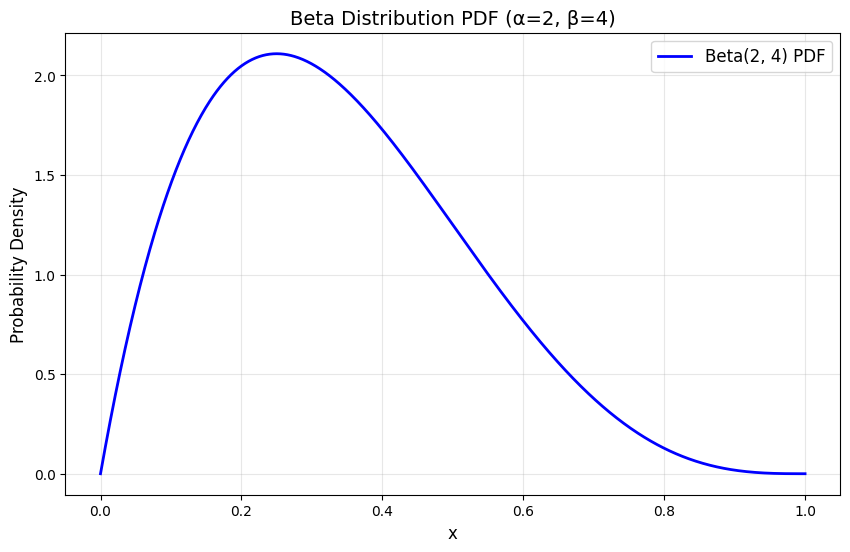

In [41]:
plotbeta(2,4)

Just as right-skewed as we wanted it to be!

We can find the posterior like so using the Binomial-Beta conjugacy formula from above:
$$\theta \mid y \sim Beta(14, 12)$$

plotbeta(14, 12)

Now to answer the trio of questions:
1. The mode of the distribution is can be found using the same formula from the last section:
$$
Mode = \frac{\alpha - 1}{\alpha + \beta -2} = \frac{14 - 1}{14 + 12 -2} = \frac{13}{24}
$$

In [43]:
print(13 / 24)

0.5416666666666666


2. The posterior probability that $\theta > 0.5$, meaning $\mathbb{P}(\theta > 0.5 \mid y)$ is equal to $1 - F(0.5)$ which can once again be calculated with SciPy.

In [12]:
from scipy.stats import beta
print(1 - beta.cdf(0.5, 14, 12))

0.6549810171127319


3. To find a 95% central credible interval, we can use the same formula and code as before and simply change the parameters of the Beta distribution.
$$a = F^{-1}(0.025) \hspace{0.5cm} \text{and} \hspace{0.5cm} b = F^{-1}(0.975)$$

In [13]:
from scipy.stats import beta
a = beta.ppf(0.025, 14, 12)
b = beta.ppf(0.975, 14, 12)
print(f"95% central credible interval: = [{a}, {b}]")

95% central credible interval: = [0.34928163399133577, 0.7220319903300534]


### 2.3 Left Skewed Prior

We can follow the same logic as before to specify a left skewed Beta distribution. We choose `0.75` as our mode.
$$\frac{\alpha - 1}{\alpha + \beta - 2} = 0.75 = \frac{3}{4}$$
$$4\alpha - 4 = 3\alpha + 3\beta - 6$$
$$\alpha = 3\beta - 2$$
Notice that if we choose $\alpha = 4$, we get $\beta = 2$, as though we've reversed the $\alpha$ and $\beta$ from our right skewed distribution. As such, this is the prior we shall proceed with.
$$\theta \sim Beta(4,2)$$

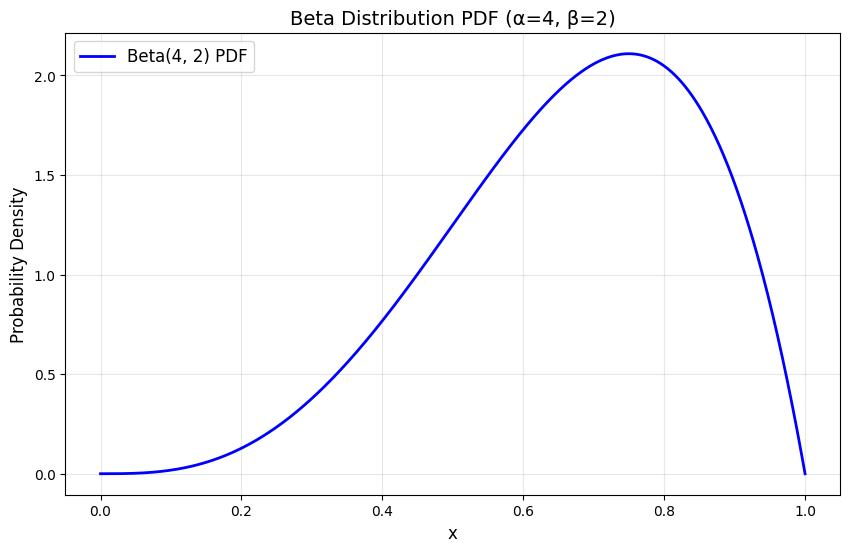

In [44]:
plotbeta(4,2)

Using the Beta-Binomial conjugacy, we have:
$$\theta \mid y \sim Beta(16, 10)$$

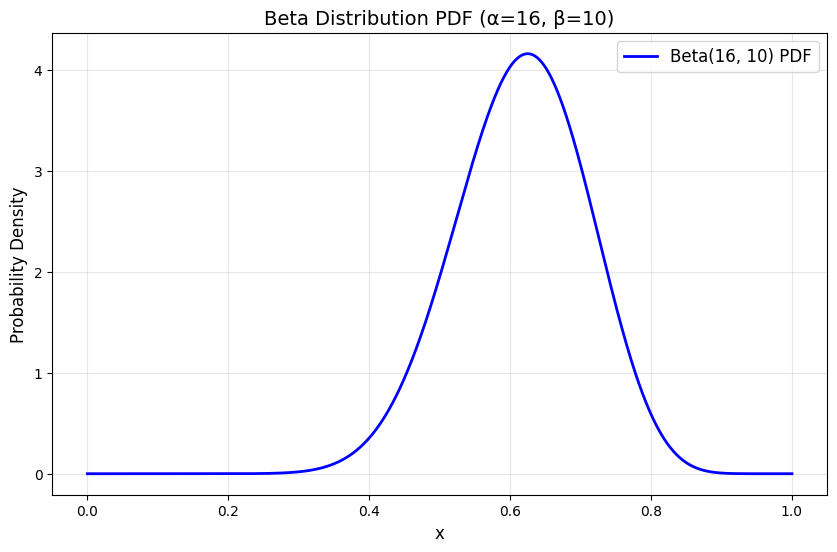

In [45]:
plotbeta(16,10)

Now to answer the trio of questions:
1. The mode of the distribution is:
$$
Mode = \frac{\alpha - 1}{\alpha + \beta -2} = \frac{16 - 1}{16 + 10 -2} = \frac{15}{24}
$$

In [47]:
print(15 / 24)

0.625


2. $\mathbb{P}(\theta > 0.5 \mid y)$ is equal to...

In [14]:
from scipy.stats import beta
print(1 - beta.cdf(0.5, 16, 10))

0.885238528251648


3. And for a 95% credible central interval, we have:

In [15]:
from scipy.stats import beta
a = beta.ppf(0.025, 16, 10)
b = beta.ppf(0.975, 16, 10)
print(f"95% central credible interval: = [{a}, {b}]")

95% central credible interval: = [0.42520634955384945, 0.788745193534858]


## 3: Prediction

Now that we've observed our data $y$ and updated our distribution for $\theta$ to obtain the posterior distribution $\theta \mid y$, we shall use the information at hand to predict the results of further data.

Suppose we proceed to survey a larger group of 500 students regarding their favorite day to have breakfast at the buffet. Define $\tilde{y}$ as the number of students out of 500 that choose monday as their favorite day (the notation is chosen to match that of BDA3). We wish to find the distribution of $\tilde{y}$ given the data $y$ which we have observed and the posterior distribution $\theta \mid y$ which we have obtained.
As in, we will be investigating $\tilde{y} \mid y, \theta$ and trying to predict how many students will choose monday.

We have computed multiple posterior PDFs for $\theta$, for this analysis we shall use the one obtained from a flat, Uniform prior:
$$\mathbb{P}(\theta \mid y) \sim Beta(13, 9)$$
We will be predicting the value for $\tilde{y}$ in two ways. Firstly, we will obtain it analytically, and then we will simulate it by generating sample $\theta$ values and then calculating. For each predictive posterior distribution, we will find the mean and discuss the general shape of the distribution.

### 3.1 Analytical Approach

We derived the below formula in section 2 (we can also cite BDA3 equation 1.3):
$$\mathbb{P}(y) = \int \mathbb{P}(y, \theta)d\theta = \int \mathbb{P}(y \mid \theta)\mathbb{P}(\theta)d\theta$$
Then, we referred to it as *marginalization*. A more informative name is the prior
predictive distribution: prior because it is not conditional on a previous observation of the
process, and predictive because it is the distribution for a quantity that is observable.

After we have observed the data $y$, we can derive the below distribution for an unknown but observable data $\tilde{y}$ (BDA3 equation 1.4):
$$\mathbb{P}(\tilde{y} \mid y) = \int \mathbb{P}(\tilde{y}, \theta \mid y) d\theta = \int \mathbb{P}(\tilde{y} \mid \theta, y)\mathbb{P}(\theta \mid y) d\theta = \int \mathbb{P}(\tilde{y} \mid \theta) \mathbb{P}(\theta \mid y) d\theta $$


To use the formula, note that:
- $\mathbb{P}(\tilde{y} \mid \theta) = {500 \choose \tilde{y}} \theta^{\tilde{y}} (1 - \theta)^{500 - \tilde{y}}$
- $\mathbb{P}(\theta \mid y) = \frac{1}{B(13, 9)} \theta^{12} (1 - \theta)^8$

So we have:
$$\mathbb{P}(\tilde{y} \mid y) = \int {500 \choose \tilde{y}} \theta^{\tilde{y}} (1 - \theta)^{500 - \tilde{y}} \frac{\theta^{12} (1 - \theta)^8}{B(13, 9)} d\theta = {500 \choose \tilde{y}} \frac{1}{B(13,9)} \int \theta^{\tilde{y} + 12} (1-\theta)^{508 - \tilde{y}} d\theta = {500 \choose \tilde{y}} \frac{B(\tilde{y} + 13, 509 - \tilde{y})}{B(13,9)}$$
We recognize this as the Beta-Binomial distribution with parameters $n = 500$, $\alpha = 13$ and $\beta = 9$. We write this as:
$$\tilde{y} \sim BetaBin(500, 13, 9)$$

Let us have a **brief  introduction to the Beta-Binomial distribution**

The Beta-Binomial distribution is a family of discrete probability distributions on a finite support of non-negative integers arising when the probability of success in each of a fixed or known number of Bernoulli trials is either unknown or random. The Beta-Binomial distribution is the binomial distribution in which the probability of success at each of $n$ trials, $\theta$, is not fixed but randomly drawn from a Beta distribution. This clearly corresponds with our situation.

The Beta-Binomial distribution has three parameters:

1. $n$ : Number of trials. (In our case, 500)
2. $\alpha$ : $\alpha$ of the Beta distribution for our success rate. (In our case, 13)
3. $\beta$ : $\beta$ of the Beta distribution for our success rate. (In our case, 9)

According to section 6.2.2 of *Univariate Discrete Distributions 3e* by Johnson, Kemp & Kotz, the mean of a Beta-Binomial distribution with parameters n, $\alpha$ and $\beta$ such as $\tilde{y} \sim BetaBin(n, \alpha, \beta)$ is:
$$\mu = \frac{n\alpha}{\alpha + \beta}$$
We can also derive this formula ourselves using the Law of Total Expectation on $\tilde{y}$ and $\theta$.

$$E(\tilde{y}) = E(E(\tilde{y} \mid \theta)) \stackrel{*}{=} E(n\theta) = nE(\theta) = \frac{n\alpha}{\alpha + \beta}$$
Where the equality marked by a star comes from the formula for Binomial expectation. Given a fixed value of $\theta$, $\tilde{y}$ is distributed as $\tilde{y} \sim Binomial(n, \theta)$ and so has expectation $E(\tilde{y}) = n\theta$. Afterwards, since $n$ is a constant, it can be brought out of the parenthesis.

Applying this formula, we have:
$$\mu = \frac{500 \cdot 13}{13 + 9}$$

In [62]:
meanie = round((500*13)/(13+9), 6)
print(f"Our mean is {meanie}")
print("We can see that this matches the result from SciPy, showing that our formula is valid.")
from scipy.stats import betabinom
print(round(betabinom.mean(500, 13, 9), 6))

Our mean is 295.454545
We can see that this matches the result from SciPy, showing that our formula is valid.
295.454545


Now we shall attempt to plot the predictive posterior using NumPy, SciPy and Matplotlib.

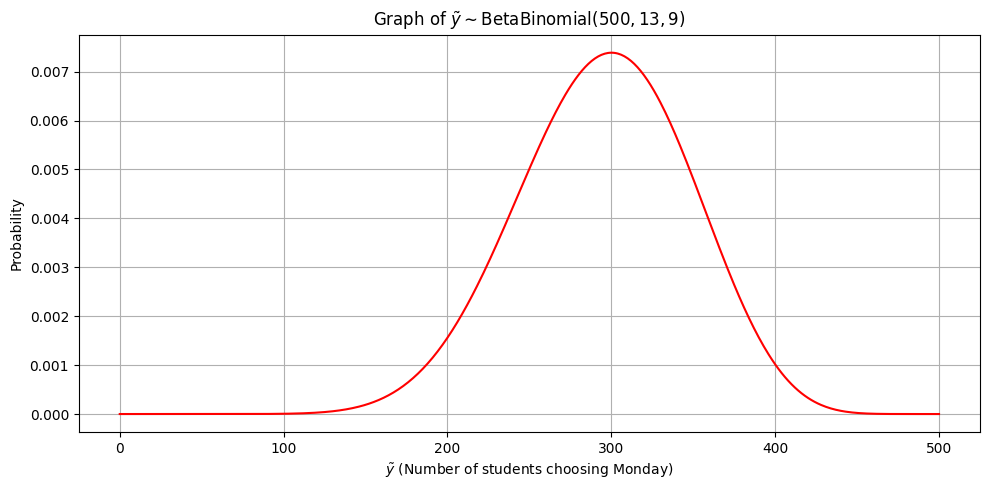

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb, beta

n = 500
a = 13
b= 9
y_values = np.arange(0, 501)

def betabin_pmf(y, n, a, b):
    coeff = comb(n, y)
    numerator = beta(y + a, n - y + b)
    denominator = beta(a, b)
    return coeff * numerator / denominator

pmf_values = betabin_pmf(y_values, n, a, b)

plt.figure(figsize=(10, 5))
plt.plot(y_values, pmf_values, lw=1.5, color='red')
plt.title('Graph of $\\tilde{y} \\sim \\mathrm{BetaBinomial}(500, 13, 9)$')
plt.xlabel(r'$\tilde{y}$ (Number of students choosing Monday)')
plt.ylabel('Probability')
plt.grid(True)
plt.tight_layout()
plt.show()

The graph above seems to be a unimodal distribution that is approximately symmetric around it's mean of $\approx 295$, reflecting the central tendency of this beta posterior. We have a mode at $\tilde{y} = 300$, as in the most probable outcome is 300 out of 500 students choosing monday as their favorite. This matches with the 0.6 figure we obtained as the most likely value for $\theta$ in our discrete example.

Our distribution is still mildly left skewed, due to to the slightly higher probability mass for $\theta > 0.5$. We can also see that the tail ends of our distribution quickly approach 0 as we near 500 and 100. Looking at the shape, it seems that a 95% central credible interval  might be a good summary of this distribution.

In [18]:
from scipy.stats import betabinom #only found out scipy has this after coding the above :p
y = betabinom(500, 13, 9)
a = y.ppf(0.025)
b = y.ppf(0.975)
print(f"95% central credible interval: = [{a}, {b}]")

95% central credible interval: = [190.0, 393.0]


Adding this interval to our plot, we have:

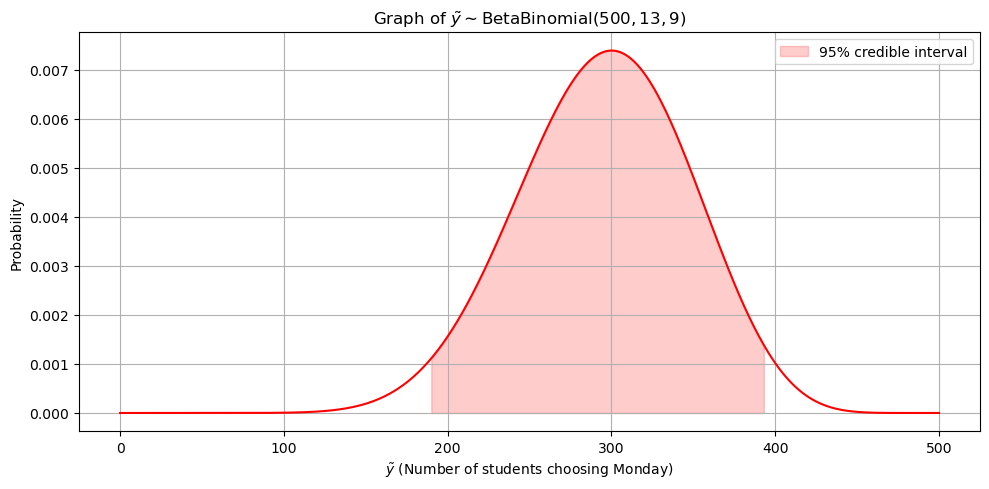

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb, beta

n = 500
a = 13
b= 9
y_values = np.arange(0, 501)

def betabin_pmf(y, n, a, b):
    coeff = comb(n, y)
    numerator = beta(y + a, n - y + b)
    denominator = beta(a, b)
    return coeff * numerator / denominator

pmf_values = betabin_pmf(y_values, n, a, b)

from scipy.stats import betabinom #only found out scipy has this after coding the above :p
y = betabinom(500, 13, 9)
lower = y.ppf(0.025)
upper = y.ppf(0.975)
credible = (y_values >= lower) & (y_values <= upper)



plt.figure(figsize=(10, 5))
plt.plot(y_values, pmf_values, lw=1.5, color='red')
plt.fill_between(y_values[credible],
    pmf_values[credible],
    color='red',
    alpha=0.2,
    label='95% credible interval')
plt.title('Graph of $\\tilde{y} \\sim \\mathrm{BetaBinomial}(500, 13, 9)$')
plt.xlabel(r'$\tilde{y}$ (Number of students choosing Monday)')
plt.ylabel('Probability')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 Simulation Approach

To simulate the posterior predictive distribution (a more frequentist approach), we shall first generate many samples of $\theta \sim Beta(13, 9)$. Then, for each sample of $\theta$, we shall generate a sample of $\tilde{y} \sim Binomial(500, \theta)$. We will end up with many samples of $\tilde{y}$ that we can use to empirically approximate the distribution of $\tilde{y}$. This method accounts for both:
- Parameter uncertainty (through the Beta distribution of $\theta \mid y$)
- Sampling variability (through the Binomial distribution of $\tilde{y} \mid \theta, y$)

We can showcase all of our samples using a plot such as a histogram. Finally, we can calculate the mean and the 95% credible interval, and try overlaying our previous graph on top of this one to see how well they fit together.

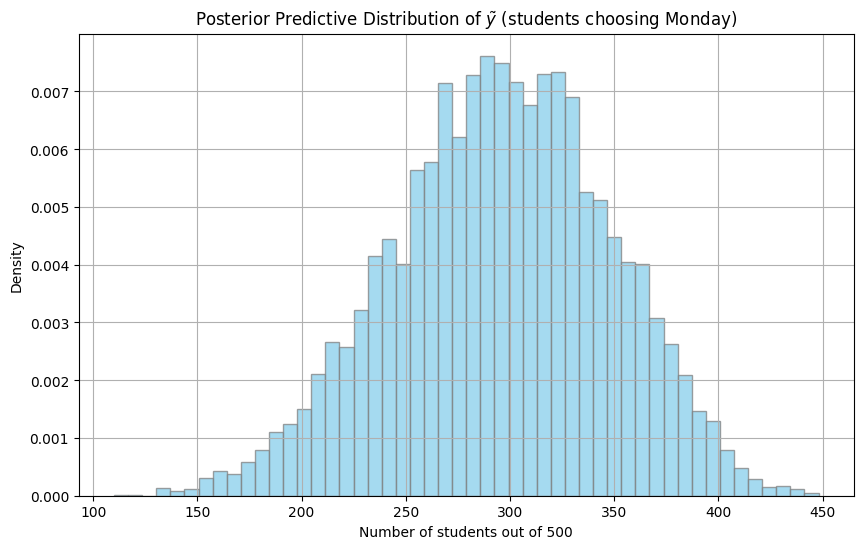

Posterior predictive mean: 295.35
95% central credible interval: [190.0, 392.0]


In [52]:
import numpy as np
import matplotlib.pyplot as plt

theta_samples = np.random.beta(13, 9, 10000)
y_tilde_samples = np.random.binomial(500, theta_samples)

mean_y = np.mean(y_tilde_samples)
lower = np.percentile(y_tilde_samples, 2.5)
upper = np.percentile(y_tilde_samples, 97.5)

plt.figure(figsize=(10, 6))
plt.hist(y_tilde_samples, bins=50, density=True, alpha=0.75, color='skyblue', edgecolor='gray')
plt.title("Posterior Predictive Distribution of $\\tilde{y}$ (students choosing Monday)")
plt.xlabel("Number of students out of 500")
plt.ylabel("Density")
plt.grid(True)
plt.show()

print(f"Posterior predictive mean: {mean_y:.2f}")
print(f"95% central credible interval: [{lower}, {upper}]")

Though each time we run the code above, we get different samples which lead to a different density and therefore different summaries (mean, credible interval) of that density; we notice that we always have a graph generally similar to the one we derived analytically. The mode seems to be always around 300, the mean around 295 with the histogram being symmetric around it, and the 95% central credible interval is always something like [190, 393] which match our results from analysis. We interpret small differences as to being due to simulation noise, which is fixed by increasing the number of samples.

Additionally, we can overlay the posterior predictive we found from analysis onto the histogram we obtained by simulation to see just how well they match.

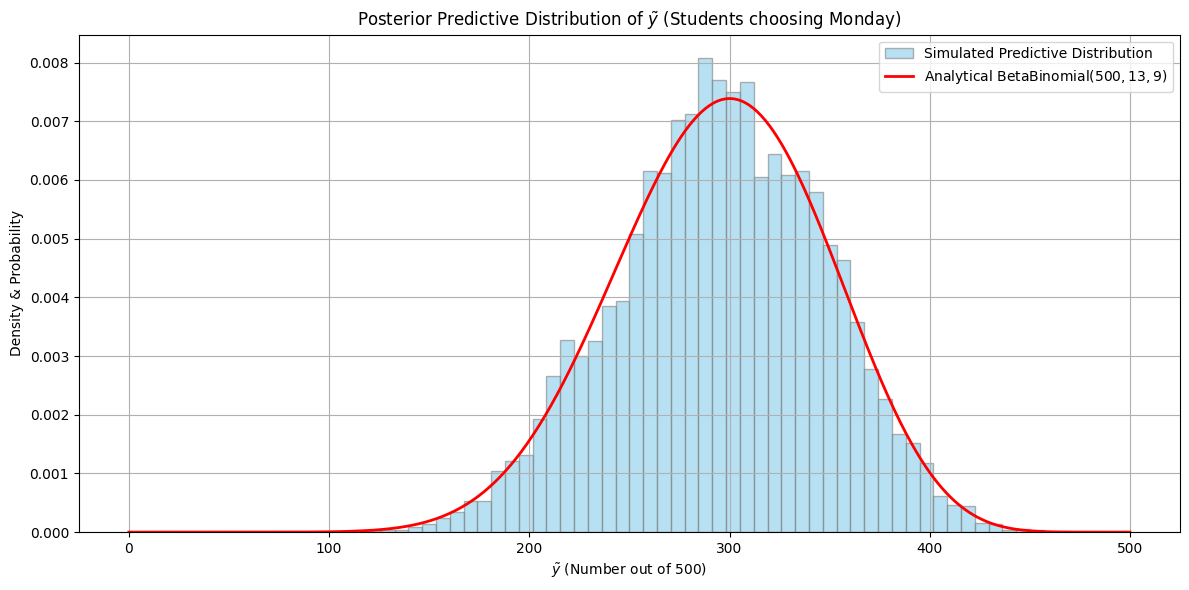

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb, beta

#for simulation:
theta_samples = np.random.beta(13, 9, 10000)
y_tilde_samples = np.random.binomial(500, theta_samples)

#from analysis
y_values = np.arange(0, 501)
def betabin_pmf(y, n, a, b):
    coeff = comb(n, y)
    numerator = beta(y + a, n - y + b)
    denominator = beta(a, b)
    return coeff * numerator / denominator
pmf_values = betabin_pmf(y_values, 500, 13, 9)

#plotting (i hate this part :<)
plt.figure(figsize=(12, 6))
plt.hist(y_tilde_samples, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='gray', label='Simulated Predictive Distribution')
plt.plot(y_values, pmf_values, lw=2, color='red', label=r'Analytical $\mathrm{BetaBinomial}(500, 13, 9)$')
plt.title('Posterior Predictive Distribution of $\\tilde{y}$ (Students choosing Monday)')
plt.xlabel(r'$\tilde{y}$ (Number out of 500)')
plt.ylabel('Density & Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

That's an awesome graph to end a project off with. Signing off :>

Thanks for reading! $\heartsuit$

"Made by two clowns 🤡🤡"

\- Radman Khodaei, 610303134

"I was really hoping to do my probability project on the topic of measure theory, but data science was actually pretty interesting! Like, you're telling me a data did this science?!"

\- Saam Yavari, 610303217